In [155]:
from matplotlib import pyplot as plt
from os import listdir
from numpy import array
from sys import argv

In [156]:
def separate_number_at_end(string):
    # Iterate backwards through the string to find the index of the first non-digit character
    index = len(string) - 1
    while index >= 0 and string[index].isdigit():
        index -= 1
    number = string[index + 1:] if index < len(string) - 1 else None
    prefix = string[:index + 1] if index >= 0 else string
    return prefix, number

def decompose_key(key):
    parts = key.split('_')
    if(len(parts) < 2):
        if(parts[0]=="step" or parts[0]=="t"):
            return (parts[0], "", "")
        else:
            return (parts[0], "", "1")
    norm_type = parts[0]
    stat_type, number = separate_number_at_end(parts[1])
    return (norm_type, stat_type, number)

def create_file_dict(filename):
    data_dict = {}
    with open(filename, 'r') as file:
        # Read the first line to get the column labels
        columns = file.readline().split()
        # Initialize dictionary values as empty lists
        for column in columns:
            decomposed_key = decompose_key(column)
            data_dict[decomposed_key] = []
        # Read the rest of the lines
        for line in file:
            values = line.split()
            for key, value in zip(data_dict, values):
                if(key[0]=="step"):
                    val = int(value)
                else:
                    val = float(value) + 1.0e-16
                data_dict[key].append(val)
    # Convert lists to NumPy arrays
    for key in data_dict:
        data_dict[key] = array(data_dict[key])
    return data_dict


In [157]:
folder = "visc_eo-ref2-kappa20-PNP-oldroyd-De1.0/res"
# get all txt files in a folder
files = listdir(folder)
files = [f for f in files if f.endswith(".txt")]
# separate the files that do not contain "_" in their name
files_no_ = [f for f in files if not "_" in f]

min_last = 0
data = {}
selected_norm = ["maxnorm"]
selected_stat = ["avg", "max"]

# get only the selected norm and stat
for filename in files_no_:
    data_file = create_file_dict(f"{folder}/{filename}")
    data_selected = {}
    for key in data_file:
        if(key[0]=="step"):
            steps = data_file[key]
            if(len(steps) > min_last):
                min_last = len(steps)
        elif(key[0]=="t"):
            tt = data_file[key]
        elif(key[0] in selected_norm and (key[1] in selected_stat)):
            data_selected[key] = data_file[key]
    dp_name = filename.split(".")[0]
    data[dp_name] = data_selected
steps = steps[:min_last]
tt = tt[:min_last]

In [158]:
# get only the selected number
numbers = set()
for dp_name in data:
    for key in data[dp_name]:
        n = key[2]
        if(not n==""):
            n = int(n)
            numbers.add(n)
    break

numbers = sorted(list(numbers))
for j,n in enumerate(numbers[::-1]):
    if(n<100):
        break
ind = len(numbers)-j-1
number_to_plot = numbers[ind]


data_number = {}
for dp_name in data:
    data_number_file = {}
    for key in data[dp_name]:
        if(key[2]==f"{number_to_plot}" or key[2]=="1"):
            data_number_file[key] = data[dp_name][key] 
    data_number[dp_name] = data_number_file

In [159]:

line_types = ['-', '--', '-.', ':']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# associate each color to the dp_name and each line type to the second string of the key when plotting
line_type_dict = {}
color_dict = {}

for dp_name in data_number:
    for key in data_number[dp_name]:
        line_type_dict[key[1]] = line_types.pop(0)
    break

for dp_name in data_number:
    if(not dp_name in color_dict):
        color_dict[dp_name] = colors.pop(0)
    

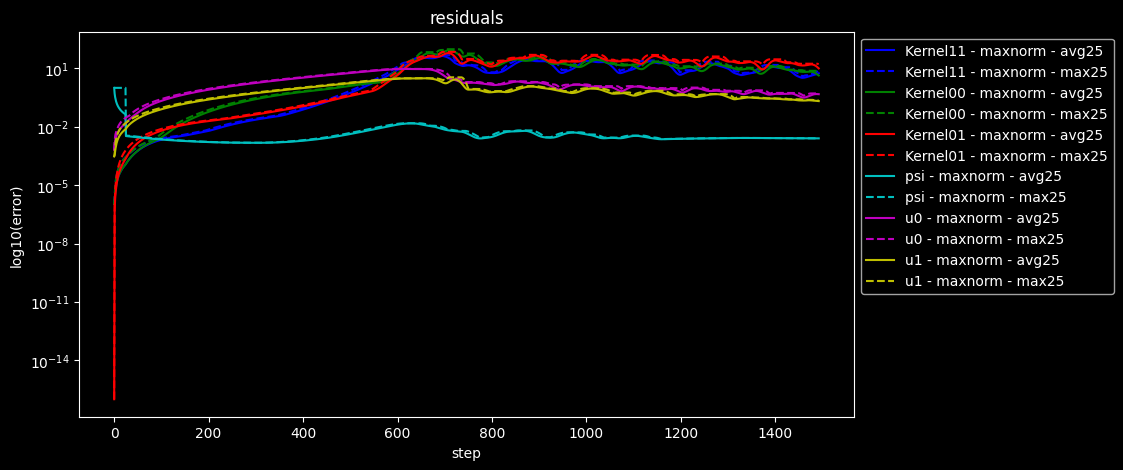

In [163]:
fig, ax = plt.subplots(figsize=(10, 5))
title = "residuals"
ax.set_title(title)
ax.set_xlabel("step")
ax.set_ylabel("log10(error)")
for dp_name in data_number:
    for key in data_number[dp_name]:
        min_last = min(min_last, len(data_number[dp_name][key]))

ini_step = 1

for dp_name in data_number:
    for key in data_number[dp_name]:
        ax.semilogy(steps[ini_step:min_last], data_number[dp_name][key][ini_step:min_last], label=f"{dp_name} - {key[0]} - {key[1]}{key[2]}", linestyle=line_type_dict[key[1]], color=color_dict[dp_name])
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 1, 1])

# create high resolution png of the plot
#plt.savefig(f"{folder}/residuals.png", dpi=300)